[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/21_selection_de_modele.ipynb)



# La sélection de modèle

Le notebook 20 s'est terminé sur un constat : le score calculé sur les données
d'entraînement est trompeur. Ce notebook en fait une méthode complète.

Comment choisir les hyperparamètres ? Comment évaluer sans se mentir ? Comment
savoir si le modèle mémorise ou comprend ? Ce sont les questions qui séparent un
`fit` bricolé d'un vrai travail de machine learning.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | Train/test : et le rôle du hasard |
| 2 | L'effet de k : underfitting et overfitting |
| 3 | La validation croisée |
| 4 | La courbe de validation : trouver le bon k |
| 5 | GridSearchCV : chercher plusieurs paramètres |
| 6 | La matrice de confusion |
| 7 | La courbe d'apprentissage : faut-il plus de données ? |

## Trois pièges annoncés

Sans `random_state`, chaque exécution donne un découpage différent donc un score
différent.

Une validation croisée `KFold` sans mélange, sur des données triées par classe,
donne des scores catastrophiques.

Et les noms d'hyperparamètres dans `GridSearchCV` doivent être exacts : une
faute de frappe fait tout planter.

Prérequis : le notebook 20.

## 1. Train/test, et le rôle du hasard

On repart du jeu iris, livré avec scikit-learn.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print('X :', X.shape)
print('y :', y.shape)
print('classes :', np.unique(y))

X : (150, 4)
y : (150,)
classes : [0 1 2]


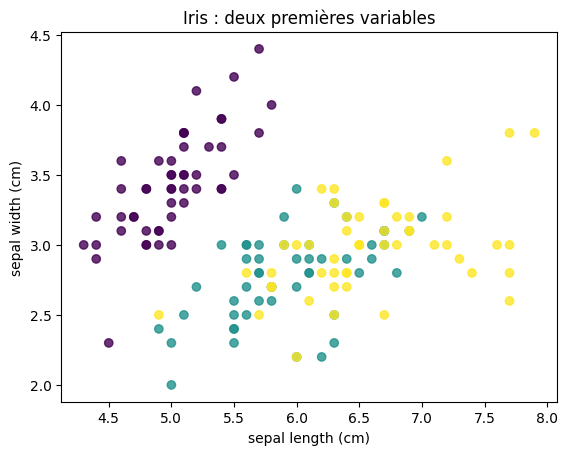

In [21]:
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Iris : deux premières variables')
plt.show()

### Séparer, et pourquoi la taille compte

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print('entraînement :', X_train.shape[0], 'fleurs')
print('test :', X_test.shape[0], 'fleurs')

entraînement : 120 fleurs
test : 30 fleurs


`test_size=0.2` réserve 20 % des données pour l'évaluation. C'est un compromis
courant : assez de données pour entraîner, assez pour évaluer de façon fiable.

Trop peu de test 5 % et le score devient instable, calculé sur une poignée
d'exemples. Trop 50 % et le modèle manque de données pour apprendre.

### Le piège du hasard

Par défaut, `train_test_split` mélange les données avant de couper. Sans
graine fixée, chaque exécution donne un découpage différent.

In [23]:
for essai in range(3):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2)
    from sklearn.neighbors import KNeighborsClassifier
    m = KNeighborsClassifier().fit(X_tr, y_tr)
    print(f'essai {essai + 1} : score test = {m.score(X_te, y_te):.3f}')

essai 1 : score test = 0.933
essai 2 : score test = 0.967
essai 3 : score test = 0.967


Trois scores différents pour le même code. Le découpage change à chaque fois, donc
le score aussi.

C'est un problème pour la reproductibilité : un lecteur qui réexécute obtiendra
d'autres chiffres. La solution est `random_state`, qui fixe le hasard.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5)

for essai in range(3):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=5)
    m = KNeighborsClassifier().fit(X_tr, y_tr)
    print(f'essai {essai + 1} : score test = {m.score(X_te, y_te):.3f}')

essai 1 : score test = 0.933
essai 2 : score test = 0.933
essai 3 : score test = 0.933


Trois fois le même score. `random_state=5` garantit un découpage identique à
chaque exécution indispensable pour un notebook publié.

Le mélange, lui, est essentiel : le jeu iris est trié par classe (50 fleurs
de chaque espèce, à la suite). Sans mélange, le test ne contiendrait qu'une seule
espèce, et l'évaluation n'aurait aucun sens. On le vérifie en section 3.

## 2. L'effet de k

Reprenons le KNN avec différentes valeurs de `k`, le nombre de voisins consultés.

In [25]:
for k in [1, 3, 6]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    print(f'k={k}  train = {model.score(X_train, y_train):.3f}  '
          f'test = {model.score(X_test, y_test):.3f}')

k=1  train = 1.000  test = 0.900
k=3  train = 0.975  test = 0.933
k=6  train = 0.983  test = 0.967


Observe le cas `k=1` : le train est à 1,0, mais le test plus bas. C'est le
surapprentissage démontré au notebook 20 avec un seul voisin, chaque point
d'entraînement est son propre voisin, d'où un score parfait qui ne reflète rien.

À mesure que `k` augmente, le train baisse et le test tend à monter, puis se
stabilise. Il y a un `k` optimal quelque part au milieu.

Les deux excès à éviter.

Un `k` trop petit colle au bruit : c'est le surapprentissage
(*overfitting*). Le modèle mémorise au lieu de généraliser.

Un `k` trop grand lisse à l'excès : c'est le sous-apprentissage
(*underfitting*). Le modèle devient trop grossier pour capter la structure.

Le bon réglage est entre les deux. Reste à le trouver sans tricher c'est tout
le sujet de ce notebook.

## 3. La validation croisée

Choisir `k` d'après le score de test pose un problème subtil : à force de régler
sur le test, on finit par s'y adapter. Le test perd alors son rôle de juge
impartial.

La solution est la validation croisée : elle n'utilise que les données
d'entraînement, découpées en plusieurs morceaux.

In [26]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv=5)
print('scores des 5 plis :', scores.round(3))
print('moyenne :', scores.mean().round(4))
print('écart-type :', scores.std().round(4))

scores des 5 plis : [1.    1.    1.    0.958 0.958]
moyenne : 0.9833
écart-type : 0.0204


`cv=5` découpe l'entraînement en 5 plis. Le modèle est entraîné 5 fois :
chaque fois, 4 plis servent à apprendre et le 5e à valider. On obtient 5 scores.

La moyenne est plus fiable qu'un seul train/test, puisqu'elle repose sur 5
évaluations. L'écart-type mesure la stabilité : petit, le modèle est régulier ;
grand, il dépend beaucoup du découpage.

C'est la différence clé avec un train/test simple : au lieu d'un score qui dépend
du hasard d'une coupe, on en moyenne cinq.

### Le piège du KFold sans mélange

`cross_val_score` gère bien le mélange par défaut. Mais si on impose un `KFold`
sans mélange sur des données triées par classe, c'est la catastrophe.

In [27]:
from sklearn.model_selection import KFold

# Sur X, y ENTIERS, qui sont triés par classe (50+50+50)
sans_melange = KFold(n_splits=5, shuffle=False)
scores_sans = cross_val_score(KNeighborsClassifier(), X, y, cv=sans_melange)

avec_melange = KFold(n_splits=5, shuffle=True, random_state=0)
scores_avec = cross_val_score(KNeighborsClassifier(), X, y, cv=avec_melange)

print('KFold sans mélange :', scores_sans.round(3), ' moyenne', scores_sans.mean().round(3))
print('KFold avec mélange :', scores_avec.round(3), ' moyenne', scores_avec.mean().round(3))

KFold sans mélange : [1.    1.    0.833 0.933 0.8  ]  moyenne 0.913
KFold avec mélange : [0.967 0.9   1.    1.    0.933]  moyenne 0.96


Sans mélange, certains plis s'effondrent. La raison : iris est trié par espèce.
Un pli sans mélange peut contenir uniquement l'espèce 0 en entraînement et
l'espèce 2 en validation le modèle n'a jamais vu la classe qu'on lui demande de
prédire.

Le mélange règle le problème, et c'est pourquoi il est activé par défaut dans
`cross_val_score`. Le piège n'apparaît que si on force un `KFold(shuffle=False)`
sur des données ordonnées.

Attention : ce mélange est justement ce qu'il ne faut pas faire sur une
série temporelle. Prédire le passé à partir du futur n'a pas de sens. Pour les
séries temporelles, il existe `TimeSeriesSplit`, qui respecte l'ordre du temps.

## 4. La courbe de validation

Pour trouver le meilleur `k`, on trace le score de validation croisée en fonction
de `k`. Deux façons de le faire.

### À la main, avec une boucle

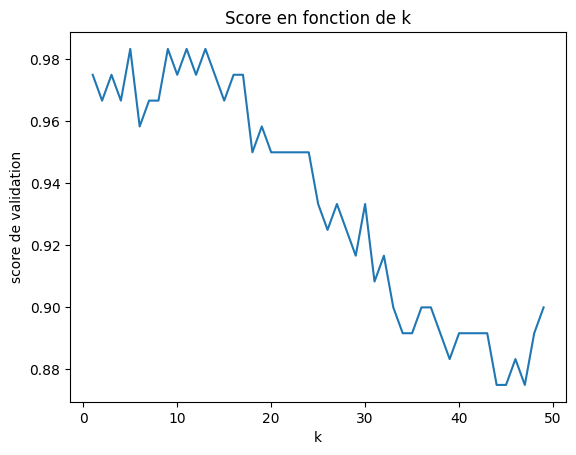

meilleur k : 5


In [28]:
val_score = []
k_range = range(1, 50)

for k in k_range:
    score = cross_val_score(KNeighborsClassifier(k), X_train, y_train, cv=5).mean()
    val_score.append(score)

plt.plot(list(k_range), val_score)
plt.xlabel('k')
plt.ylabel('score de validation')
plt.title('Score en fonction de k')
plt.show()

meilleur_k = list(k_range)[np.argmax(val_score)]
print('meilleur k :', meilleur_k)

`argmax` donne la position du maximum l'idiome du notebook 12. On lit le `k` qui
maximise le score de validation.

### Avec validation_curve

scikit-learn automatise ça, et renvoie aussi le score d'entraînement, ce qui
permet de voir le surapprentissage.

In [29]:
from sklearn.model_selection import validation_curve

model = KNeighborsClassifier()
k = np.arange(1, 50)

train_score, val_score = validation_curve(
    model, X_train, y_train,
    param_name='n_neighbors',
    param_range=k,
    cv=5)

print('train_score :', train_score.shape, '-> (valeurs de k, plis)')
print('val_score   :', val_score.shape)

train_score : (49, 5) -> (valeurs de k, plis)
val_score   : (49, 5)


Le piège de la syntaxe : `param_name` et `param_range` doivent être nommés.
Les passer en position échoue dans les versions récentes.

Et `param_name='n_neighbors'` doit être le nom exact de l'hyperparamètre. Pour
le vérifier :

```python
print(KNeighborsClassifier().get_params().keys())
```

Le résultat a la forme `(49, 5)` : une ligne par valeur de `k`, une colonne par
pli. On moyenne sur les plis avec `axis=1`.

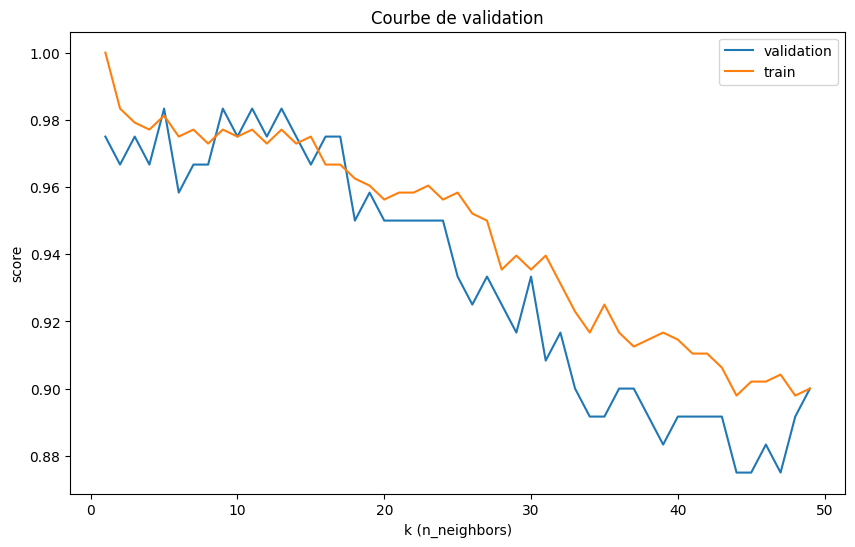

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(k, val_score.mean(axis=1), label='validation')
plt.plot(k, train_score.mean(axis=1), label='train')
plt.xlabel('k (n_neighbors)')
plt.ylabel('score')
plt.legend()
plt.title('Courbe de validation')
plt.show()

La lecture de cette courbe est essentielle.

À gauche (`k` petit) : le train est très haut, la validation plus basse. L'écart
entre les deux est le surapprentissage. Le modèle mémorise.

À droite (`k` grand) : les deux courbes baissent et se rejoignent. Le modèle
devient trop simple sous-apprentissage.

Le bon `k` est là où la validation atteint son maximum, avant que le
surapprentissage ou le sous-apprentissage ne dégradent tout.

Cette courbe est l'outil central du réglage d'un hyperparamètre. Elle montre
d'un coup d'œil les deux régimes et le point d'équilibre.

## 5. GridSearchCV : plusieurs paramètres

La courbe de validation règle un hyperparamètre. Quand il y en a plusieurs,
`GridSearchCV` teste toutes les combinaisons.

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': np.arange(1, 20),
    'metric': ['euclidean', 'manhattan'],
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print('meilleur score :', round(grid.best_score_, 4))
print('meilleurs params :', grid.best_params_)

meilleur score : 0.9833
meilleurs params : {'metric': 'euclidean', 'n_neighbors': np.int64(5)}


Ce que fait GridSearchCV.Il teste chaque combinaison ici 19 valeurs de `k`
× 2 métriques = 38 modèles chacune évaluée par validation croisée à 5 plis, soit
190 entraînements. Puis il retient la meilleure dans `best_params_`.

### Récupérer et évaluer le meilleur modèle

In [32]:
meilleur_model = grid.best_estimator_

print('Score sur le TEST :', round(meilleur_model.score(X_test, y_test), 4))

Score sur le TEST : 0.9333


`best_estimator_` est le modèle déjà réentraîné avec les meilleurs paramètres.

C'est ici et seulement ici qu'on touche au test. Toute la recherche s'est
faite en validation croisée sur l'entraînement. Le test n'intervient qu'à la
toute fin, pour une évaluation finale et honnête une seule fois.

C'est la discipline centrale du machine learning : le test est sacré, on ne s'en
sert jamais pour régler quoi que ce soit.

Le coût combinatoire. Chaque paramètre ajouté multiplie le nombre de
combinaisons. Trois paramètres à 10 valeurs font déjà 1000 combinaisons × 5 plis
= 5000 entraînements. Pour de grandes grilles, `RandomizedSearchCV` en teste un
échantillon au hasard, bien plus rapide.

## 6. La matrice de confusion

Le score global cache le détail des erreurs. La matrice de confusion montre
qui est confondu avec qui.

In [33]:
from sklearn.metrics import confusion_matrix

predictions = meilleur_model.predict(X_test)
cm = confusion_matrix(y_test, predictions)

print(cm)

[[ 8  0  0]
 [ 0  9  2]
 [ 0  0 11]]


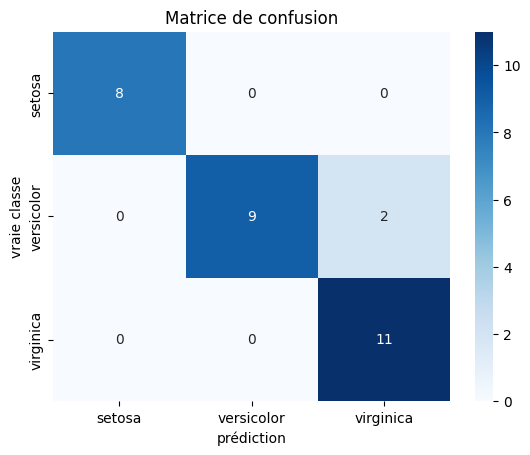

In [34]:
import seaborn as sns

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('prédiction')
plt.ylabel('vraie classe')
plt.title('Matrice de confusion')
plt.show()

Comment la lire. Chaque ligne est la vraie classe, chaque colonne la
prédiction.

La diagonale contient les prédictions correctes. Tout ce qui est hors
diagonale est une erreur, et sa position dit laquelle : une valeur en ligne
*versicolor*, colonne *virginica*, signifie qu'une *versicolor* a été prise pour
une *virginica*.

Sur iris, les erreurs éventuelles sont presque toujours entre *versicolor* et
*virginica* les deux espèces qui se chevauchaient sur le `pairplot` du notebook
19. *Setosa*, bien séparée, n'est jamais confondue.

C'est l'intérêt de la matrice sur un simple score : elle dit où le modèle se
trompe, pas seulement combien de fois. Sur un problème médical, confondre
« sain » avec « malade » n'a pas la même gravité que l'inverse la matrice le
révèle, le score global le cache.

## 7. La courbe d'apprentissage

Dernière question : le modèle bénéficierait-il de plus de données ? La courbe
d'apprentissage y répond.

In [35]:
from sklearn.model_selection import learning_curve

N, train_score, val_score = learning_curve(
    meilleur_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5)

print('tailles testées :', N)

tailles testées : [ 9 19 28 38 48 57 67 76 86 96]


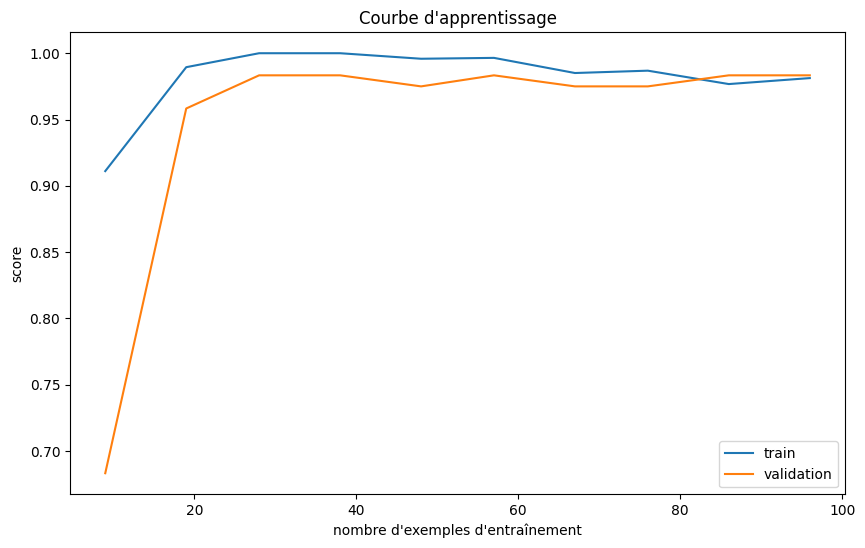

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(N, train_score.mean(axis=1), label='train')
plt.plot(N, val_score.mean(axis=1), label='validation')
plt.xlabel("nombre d'exemples d'entraînement")
plt.ylabel('score')
plt.legend()
plt.title("Courbe d'apprentissage")
plt.show()

`learning_curve` réentraîne le modèle avec des quantités croissantes de données 10 %, puis 20 %, jusqu'à 100 % et trace le score à chaque étape.

Comment l'interpréter.

Si la courbe de validation monte encore à droite, le modèle a soif de données :
en ajouter améliorerait les résultats.

Si elle a atteint un plateau, plus de données ne servirait à rien. Pour
progresser, il faudrait un meilleur modèle ou de meilleures variables, pas plus
d'exemples.

L'écart entre train et validation raconte la même histoire que la courbe de
validation : un grand écart persistant signale du surapprentissage.

Cette courbe évite un gaspillage courant collecter des milliers de données
supplémentaires alors que le modèle a déjà plafonné. Elle dit si l'effort en vaut
la peine.

## 8. Mémo

### Les outils

| Outil | Rôle |
|---|---|
| `train_test_split` | séparer, avec `random_state` |
| `cross_val_score` | valider sur plusieurs plis |
| `validation_curve` | régler un hyperparamètre |
| `GridSearchCV` | régler plusieurs paramètres |
| `confusion_matrix` | détailler les erreurs |
| `learning_curve` | faut-il plus de données ? |

### Le vocabulaire

| Terme | Signification |
|---|---|
| Surapprentissage | train haut, validation basse ; le modèle mémorise |
| Sous-apprentissage | les deux bas ; le modèle est trop simple |
| Validation croisée | moyenne sur plusieurs découpages |
| Hyperparamètre | réglage choisi avant l'entraînement |

### La discipline

1. Séparer train et test au début, avec `random_state`.
2. Régler les hyperparamètres uniquement sur l'entraînement (validation croisée).
3. Évaluer sur le test une seule fois, à la fin.

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| Pas de `random_state` | score différent à chaque exécution |
| `KFold(shuffle=False)` sur données triées | plis catastrophiques |
| Mélanger une série temporelle | prédit le passé avec le futur |
| Faute dans `param_name` | `ValueError` |
| Régler sur le test | test corrompu, évaluation faussée |
| Juger sur le seul score | on rate où sont les erreurs |

## 9. Exercices

**Exercice 1**

Sur iris, trace la courbe de validation pour l'hyperparamètre `max_depth` d'un
`DecisionTreeClassifier`, de 1 à 20. Identifie la profondeur optimale, et repère
visuellement les zones de sous-apprentissage et de surapprentissage.

**Exercice 2**

Compare `KNeighborsClassifier`, `LogisticRegression` et `RandomForestClassifier`
par validation croisée sur iris. Pour chacun, affiche la moyenne et
l'écart-type des scores. Lequel est le plus performant ? Le plus stable ? Sont-ce
les mêmes ?

**Exercice 3**

Ce code prétend trouver le meilleur modèle et l'évaluer :

```python
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X, y) # sur toutes les données
print('Meilleur score :', grid.best_score_)
model = grid.best_estimator_
print('Score final :', model.score(X, y))
```

Il contient une faute méthodologique grave. Trouve-la, explique pourquoi le
« score final » est trompeur, puis corrige pour obtenir une évaluation honnête.

## Pour continuer

Le notebook suivant porte sur le prétraitement : normaliser les variables, encoder
les catégories, gérer les valeurs manquantes. C'est ce qui prépare les données
avant le modèle et le KNN de ce notebook y est très sensible, car il repose sur
des distances.

On y verra aussi comment enchaîner prétraitement et modèle dans un `Pipeline`,
pour que la validation croisée reste honnête même avec des étapes de
transformation.

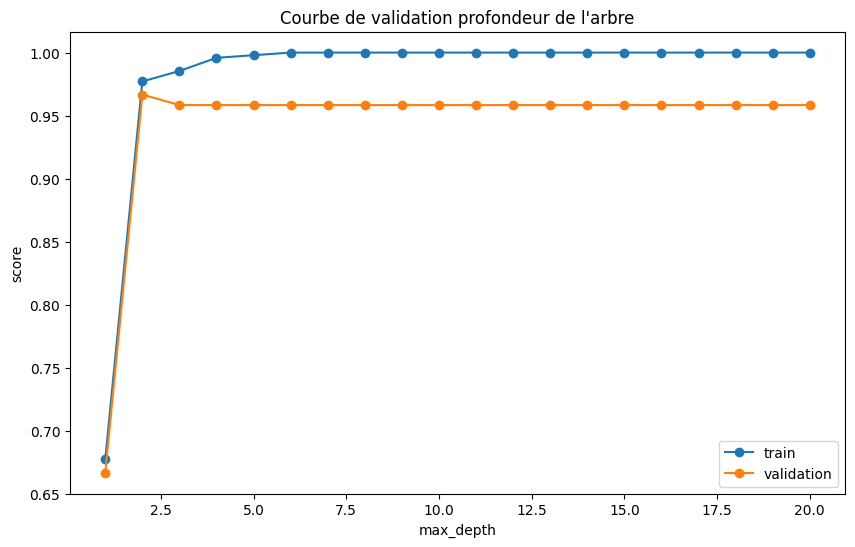

profondeur optimale : 2


In [37]:
# Exercice 1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

profondeurs = np.arange(1, 21)

train_score, val_score = validation_curve(
    DecisionTreeClassifier(random_state=0),
    X_train, y_train,
    param_name='max_depth',
    param_range=profondeurs,
    cv=5)

plt.figure(figsize=(10, 6))
plt.plot(profondeurs, train_score.mean(axis=1), label='train', marker='o')
plt.plot(profondeurs, val_score.mean(axis=1), label='validation', marker='o')
plt.xlabel('max_depth')
plt.ylabel('score')
plt.legend()
plt.title("Courbe de validation profondeur de l'arbre")
plt.show()

meilleure = profondeurs[np.argmax(val_score.mean(axis=1))]
print('profondeur optimale :', meilleure)

In [38]:
print('max_depth=1 :')
print('train :', round(train_score.mean(axis=1)[0], 3))
print('validation :', round(val_score.mean(axis=1)[0], 3))

max_depth=1 :
train : 0.677
validation : 0.667


In [39]:
arbre = DecisionTreeClassifier(max_depth=int(meilleure), random_state=0)
arbre.fit(X_train, y_train)
print('score test :', round(arbre.score(X_test, y_test), 3))

score test : 0.9


In [40]:
# Exercice 2

In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modeles = {
    'KNN': KNeighborsClassifier(),
    'Logistique': LogisticRegression(max_iter=1000),
    'Forêt': RandomForestClassifier(random_state=0),
}

print(f'{"modèle":<12} {"moyenne":>8} {"écart-type":>11}')
print('-' * 33)

for nom, model in modeles.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f'{nom:<12} {scores.mean():>8.3f} {scores.std():>11.3f}')

modèle        moyenne  écart-type
---------------------------------
KNN             0.983       0.020
Logistique      0.967       0.017
Forêt           0.958       0.026


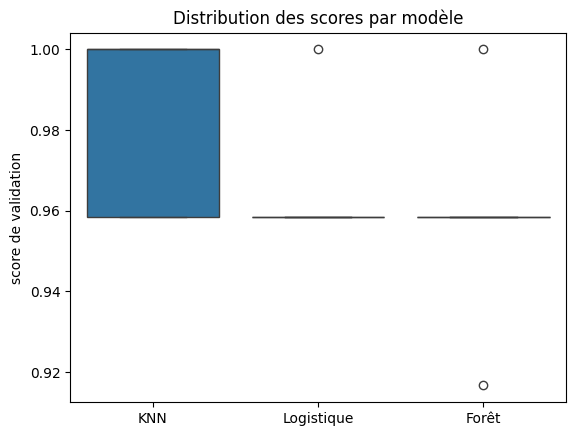

In [42]:
import seaborn as sns

resultats = {nom: cross_val_score(model, X_train, y_train, cv=5)
             for nom, model in modeles.items()}

sns.boxplot(data=resultats)
plt.ylabel('score de validation')
plt.title('Distribution des scores par modèle')
plt.show()

In [43]:
# Exericice 3

In [44]:
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X, y) # sur toutes les données
print('Meilleur score :', grid.best_score_)
model = grid.best_estimator_
print('Score final :', model.score(X, y))

Meilleur score : 0.9800000000000001
Score final : 0.9733333333333334


In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 20)}

# La version fautive
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X, y)
print('Score sur toutes les données :', round(grid.best_estimator_.score(X, y), 3))

Score sur toutes les données : 0.973


In [46]:
# 1. Réserver un test AVANT toute recherche
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5)

# 2. La recherche n'utilise QUE l'entraînement
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print('Meilleurs params :', grid.best_params_)
print('Score de validation :', round(grid.best_score_, 3))

# 3. Le test n'intervient qu'ICI, une seule fois
model = grid.best_estimator_
print('Score sur le TEST :', round(model.score(X_test, y_test), 3))

Meilleurs params : {'n_neighbors': np.int64(5)}
Score de validation : 0.983
Score sur le TEST : 0.933
